# Titanic 25 - Combined Ticket Features Experiment

## 가설

Ticket 그룹 내 비가족 동행자 규모, 1인당 운임, 비가족 동행자 비율을 동시에 제공하면 Ticket 단위의 그룹 구조와 경제적 특성을 모델이 더 구체적으로 학습할 수 있어 AUC가 개선될 수 있다.

**Baseline: Titanic 21**

추가 Feature는 `NonFamilyGroupSize`, `TicketFarePerPerson`, `NonFamilyGroupRatio` 세 개뿐이다. Titanic 21의 전처리, CatBoost 설정, random_state=42, 25% stratified holdout, 5-fold Stratified CV를 그대로 유지한다.

음수 파생값은 `FamilySize`가 동일 Ticket 내부 가족 수가 아니라 전체 동승 가족 수이기 때문에 발생할 수 있다. Titanic 22/24와 동일하게 값을 0으로 clip하지 않는다.


# 1. 데이터 수집 및 확인


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

from common.evaluations import get_auc_score
from common.feature_experiments import fit_cat, baseline_parameters
from common.preprocessing import TitanicPreprocessor
from common.utils import train_test_split_by_target

ROOT = Path.cwd()
train = pd.read_csv(ROOT / "csv" / "train.csv")
test = pd.read_csv(ROOT / "csv" / "test.csv")
submission = pd.read_csv(ROOT / "csv" / "submission.csv")
ADDED_FEATURES = ["NonFamilyGroupSize", "TicketFarePerPerson", "NonFamilyGroupRatio"]

print("train:", train.shape, "test:", test.shape, "submission:", submission.shape)
display(train.head())
display(test.head())


train: (916, 12) test: (393, 11) submission: (393, 2)
   passengerid  survived  pclass  ...     fare cabin  embarked
0            0         0       2  ...  12.8750   NaN         S
1            1         0       3  ...   7.7500   NaN         Q
2            2         1       1  ...  93.5000   B69         S
3            3         1       3  ...   7.7958   NaN         S
4            4         0       2  ...  26.0000   NaN         S

[5 rows x 12 columns]
   passengerid  pclass  ... cabin embarked
0          916       3  ...   NaN        Q
1          917       2  ...   NaN        S
2          918       3  ...   NaN        Q
3          919       3  ...   NaN        S
4          920       1  ...   NaN        S

[5 rows x 11 columns]


# 2. 메타 정보 확인


In [2]:
print("train columns:", train.columns.tolist())
print("test columns:", test.columns.tolist())
print("train missing ratio:\n", train.isna().mean().sort_values(ascending=False).to_string())
print("test missing ratio:\n", test.isna().mean().sort_values(ascending=False).to_string())
train_only = set(train.columns) - set(test.columns)
test_only = set(test.columns) - set(train.columns)
print("train only:", train_only, "test only:", test_only)


train columns: ['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
test columns: ['passengerid', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
train missing ratio:
 cabin          0.783843
age            0.196507
embarked       0.001092
passengerid    0.000000
name           0.000000
pclass         0.000000
survived       0.000000
gender         0.000000
parch          0.000000
sibsp          0.000000
fare           0.000000
ticket         0.000000
test missing ratio:
 cabin          0.753181
age            0.211196
fare           0.002545
embarked       0.002545
name           0.000000
passengerid    0.000000
pclass         0.000000
parch          0.000000
sibsp          0.000000
gender         0.000000
ticket         0.000000
train only: {'survived'} test only: set()


# 3. Target 정의

train에만 있는 Target과 제출 템플릿을 교차 확인하고 ID는 Feature에서 제외한다.


In [3]:
assert len(train_only) == 1 and not test_only
target_col = next(iter(train_only))
id_col = submission.columns[0]
assert submission.columns.tolist() == [id_col, target_col]
assert train[id_col].is_unique and test[id_col].is_unique
assert set(train[id_col]).isdisjoint(test[id_col])
X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
assert X.columns.equals(X_test_raw.columns)
print("target:", target_col, "ID:", id_col, "X/y:", X.shape, y.shape)


target: survived ID: passengerid X/y: (916, 10) (916,)


# 4. Target 데이터 분석 및 분리

EDA와 전처리 전에 Titanic 21과 동일하게 seed 42, stratify, validation 25%로 분리한다.


In [4]:
assert set(y.unique()) == {0, 1}
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]
X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]
assert len(train_part) == 687 and len(valid_part) == 229
assert set(train_part[id_col]).isdisjoint(valid_part[id_col])
print("train/validation:", X_tr_raw.shape, X_valid_raw.shape)
print(y_tr.value_counts(normalize=True).sort_index().to_string())


train/validation: (687, 10) (229, 10)
survived
0    0.621543
1    0.378457


# 5. 핵심 Feature 및 데이터 누수 방지

Ticket 빈도는 전처리 객체의 `fit_missing`에서 전달받은 학습 표본만 사용해 계산한다. Holdout에서는 train split으로 fit 후 validation에 transform하고, CV에서는 각 fold train으로 새 전처리 객체를 fit한다. Test에는 전체 train으로 fit한 통계를 적용한다.


In [5]:
class Titanic25Preprocessor(TitanicPreprocessor):
    """Titanic 21에 기존 22~24 Ticket Feature 세 개만 동시에 추가한다."""

    def fit_missing(self, X):
        super().fit_missing(X)
        self.ticket_counts_ = X["ticket"].value_counts()
        return self

    def feature_frame(self, raw, clean):
        data = self.make_features(clean)
        # Titanic 21: LogFare 유지, IsAlone 제거
        data["LogFare"] = np.log1p(data["fare"])
        data = data.drop(columns="IsAlone")

        # Titanic 22~24와 동일한 leakage-safe TicketGroupSize 정의
        ticket_group_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)
        non_family_group_size = ticket_group_size - data["FamilySize"]

        data["NonFamilyGroupSize"] = non_family_group_size
        data["TicketFarePerPerson"] = data["fare"] / ticket_group_size
        data["NonFamilyGroupRatio"] = non_family_group_size / ticket_group_size
        # TicketGroupSize는 중간 계산값이며 모델 Feature로 추가하지 않는다.
        return self.select_features(data)

    def fit_transform(self, X):
        self.fit_missing(X)
        data = self.feature_frame(X, self.transform_missing(X))
        self.fit_encoding(data)
        return self.transform_encoding(data)

    def transform(self, X):
        data = self.feature_frame(X, self.transform_missing(X))
        return self.transform_encoding(data)


def feature_diagnostics(label, raw, features, prep):
    ticket_group_size = raw["ticket"].map(prep.ticket_counts_).fillna(1).clip(lower=1).astype(float)
    checks = {
        "TicketGroupSize_zero": int((ticket_group_size == 0).sum()),
        "NonFamilyGroupSize_negative": int((features["NonFamilyGroupSize"] < 0).sum()),
        "NonFamilyGroupRatio_negative": int((features["NonFamilyGroupRatio"] < 0).sum()),
        "NaN": int(features[ADDED_FEATURES].isna().sum().sum()),
        "Inf": int(np.isinf(features[ADDED_FEATURES].to_numpy()).sum()),
    }
    print(f"[{label}]")
    print("TicketGroupSize == 0 개수:", checks["TicketGroupSize_zero"])
    print("NonFamilyGroupSize 음수 개수:", checks["NonFamilyGroupSize_negative"])
    print("NonFamilyGroupRatio 음수 개수:", checks["NonFamilyGroupRatio_negative"])
    print("NaN 개수:", checks["NaN"])
    print("Inf 개수:", checks["Inf"])
    return checks


# 6. 데이터 전처리


## 6-1. 결측치 처리

학습 부분에서만 결측치 통계를 fit하고 validation에는 transform만 적용한다.


In [6]:
prep = Titanic25Preprocessor().fit_missing(X_tr_raw)
X_tr_clean = prep.transform_missing(X_tr_raw)
X_valid_clean = prep.transform_missing(X_valid_raw)
assert not X_tr_clean.isna().any().any()
assert not X_valid_clean.isna().any().any()
print("제외 결측 컬럼:", prep.drop_missing_)
print("age 그룹 중앙값:\n", prep.age_groups_.to_string())


제외 결측 컬럼: ['cabin']
age 그룹 중앙값:
 gender  pclass
female  1         35.0
        2         27.0
        3         22.0
male    1         42.0
        2         30.0
        3         24.0


## 6-2. Feature 생성 및 분포 확인


In [7]:
X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)
X_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)
assert all(feature in X_tr_features.columns for feature in ADDED_FEATURES)
assert "TicketGroupSize" not in X_tr_features.columns
assert "IsAlone" not in X_tr_features.columns
print("모델 입력 전 Feature:", X_tr_features.columns.tolist())
display(X_tr_features[ADDED_FEATURES].describe())
for feature in ADDED_FEATURES:
    print(f"\n[{feature} value counts]")
    print(X_tr_features[feature].value_counts().sort_index().head(30).to_string())


모델 입력 전 Feature: ['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'LogFare', 'NonFamilyGroupSize', 'TicketFarePerPerson', 'NonFamilyGroupRatio']
       NonFamilyGroupSize  TicketFarePerPerson  NonFamilyGroupRatio
count          687.000000           687.000000           687.000000
mean            -0.285298            20.154111            -0.253982
std              1.225388            29.832799             0.724754
min             -8.000000             0.000000            -6.000000
25%              0.000000             7.787500             0.000000
50%              0.000000            10.500000             0.000000
75%              0.000000            25.927100             0.000000
max              6.000000           512.329200             0.857143

[NonFamilyGroupSize value counts]
NonFamilyGroupSize
-8.0      3
-6.0      1
-5.0      4
-4.0      8
-3.0     15
-2.0     38
-1.0     99
 0.0    451
 1.0     48
 2.0     12
 4.0      7
 6.0      1

[TicketFarePe

## 6-3. 음수·0·NaN·Inf 검증

음수는 오류로 간주해 clip하지 않는다. `FamilySize`는 동일 Ticket 내부 가족 수가 아니며, leakage 방지를 위해 Ticket 빈도도 현재 학습 표본에서만 계산하므로 `TicketGroupSize - FamilySize`가 음수가 될 수 있다.


In [8]:
holdout_train_checks = feature_diagnostics("holdout train", X_tr_raw, X_tr_features, prep)
holdout_valid_checks = feature_diagnostics("holdout validation", X_valid_raw, X_valid_features, prep)
assert holdout_train_checks["TicketGroupSize_zero"] == 0
assert holdout_valid_checks["TicketGroupSize_zero"] == 0
assert holdout_train_checks["NaN"] == holdout_train_checks["Inf"] == 0
assert holdout_valid_checks["NaN"] == holdout_valid_checks["Inf"] == 0


[holdout train]
TicketGroupSize == 0 개수: 0
NonFamilyGroupSize 음수 개수: 168
NonFamilyGroupRatio 음수 개수: 168
NaN 개수: 0
Inf 개수: 0
[holdout validation]
TicketGroupSize == 0 개수: 0
NonFamilyGroupSize 음수 개수: 96
NonFamilyGroupRatio 음수 개수: 96
NaN 개수: 0
Inf 개수: 0


## 6-4. Target과의 관계

분석은 train split에서만 수행하며 모델 Feature 정의에는 영향을 주지 않는다.


In [9]:
for feature in ADDED_FEATURES:
    relation = pd.DataFrame({feature: X_tr_features[feature], target_col: y_tr})
    relation["bin"] = pd.qcut(relation[feature], q=4, duplicates="drop")
    print(f"\n[{feature} vs target]")
    print(relation.groupby("bin", observed=True)[target_col].agg(["size", "mean"]).to_string())



[NonFamilyGroupSize vs target]
               size      mean
bin                          
(-8.001, 0.0]   619  0.366721
(0.0, 6.0]       68  0.485294

[TicketFarePerPerson vs target]
                   size      mean
bin                              
(-0.001, 7.788]     172  0.290698
(7.788, 10.5]       184  0.282609
(10.5, 25.927]      159  0.377358
(25.927, 512.329]   172  0.569767

[NonFamilyGroupRatio vs target]
               size      mean
bin                          
(-6.001, 0.0]   619  0.366721
(0.0, 0.857]     68  0.485294


## 6-5. 데이터 인코딩

Titanic 21과 같은 One-Hot Encoding을 학습 부분에만 fit한다.


In [10]:
prep.fit_encoding(X_tr_features)
X_tr_model = prep.transform_encoding(X_tr_features)
X_valid_model = prep.transform_encoding(X_valid_features)
assert X_tr_model.columns.equals(X_valid_model.columns)
assert all(feature in X_tr_model.columns for feature in ADDED_FEATURES)
assert "TicketGroupSize" not in X_tr_model.columns
print("범주형:", prep.cat_cols_)
print("인코딩 후:", X_tr_model.shape, X_valid_model.shape)
print("Encoded Feature 목록:", X_tr_model.columns.tolist())


범주형: ['gender', 'embarked']
인코딩 후: (687, 15) (229, 15)
Encoded Feature 목록: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'NonFamilyGroupSize', 'TicketFarePerPerson', 'NonFamilyGroupRatio', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## 6-6. 데이터 스케일링

Titanic 21과 같은 트리 기반 CatBoost이므로 스케일링은 생략한다.


In [11]:
assert np.isfinite(X_tr_model.to_numpy()).all()
assert np.isfinite(X_valid_model.to_numpy()).all()
assert X_tr_model.index.equals(y_tr.index)
print("NaN/Inf 없음, index 일치")


NaN/Inf 없음, index 일치


# 7. 모델 학습

Titanic 21과 같은 CatBoost 기본 파라미터와 random_state=42를 유지한다.


In [12]:
model = fit_cat(X_tr_model, y_tr)
assert model.get_params() == baseline_parameters()
print("model:", model.__class__.__name__)
print("parameters:", model.get_params())


model: CatBoostClassifier
parameters: {'verbose': 0, 'allow_writing_files': False, 'random_state': 42, 'cat_features': []}


# 8. Evaluation - AUC


In [13]:
positive_index = list(model.classes_).index(1)
train_probability = model.predict_proba(X_tr_model)[:, positive_index]
valid_probability = model.predict_proba(X_valid_model)[:, positive_index]
train_auc = get_auc_score(y_tr, train_probability)
validation_auc = get_auc_score(y_valid, valid_probability)
gap = train_auc - validation_auc
print(f"Train AUC: {train_auc:.6f}")
print(f"Validation AUC: {validation_auc:.6f}")
print(f"Train / Validation Gap: {gap:.6f}")


Train AUC: 0.967303
Validation AUC: 0.896731
Train / Validation Gap: 0.070572


# 9. 5-Fold Stratified CV

각 fold마다 새로운 전처리 객체를 생성하고 fold train의 Ticket 통계만 fit한다.


In [14]:
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
for fold, (train_index, valid_index) in enumerate(splitter.split(X, y), 1):
    fold_prep = Titanic25Preprocessor()
    X_fold_train = fold_prep.fit_transform(X.iloc[train_index])
    X_fold_valid = fold_prep.transform(X.iloc[valid_index])
    fold_model = fit_cat(X_fold_train, y.iloc[train_index])
    fold_positive = list(fold_model.classes_).index(1)
    fold_auc = get_auc_score(
        y.iloc[valid_index],
        fold_model.predict_proba(X_fold_valid)[:, fold_positive],
    )
    fold_scores.append(fold_auc)
    print(f"Fold {fold}: {fold_auc:.6f}")
cv_mean = float(np.mean(fold_scores))
cv_std = float(np.std(fold_scores, ddof=1))
print(f"5-Fold CV Mean: {cv_mean:.6f}")
print(f"5-Fold CV Std: {cv_std:.6f}")


Fold 1: 0.883396
Fold 2: 0.915395
Fold 3: 0.893656
Fold 4: 0.888762
Fold 5: 0.911518
5-Fold CV Mean: 0.898545
5-Fold CV Std: 0.014154


# 10. Titanic 21~25 비교


In [15]:
comparison = pd.DataFrame([
    {"Version": "Titanic 21", "Features": "Baseline", "Train AUC": 0.964155, "Validation AUC": 0.903480, "Gap": 0.060675, "CV Mean": 0.900862, "CV Std": 0.018278},
    {"Version": "Titanic 22", "Features": "+ NonFamilyGroupSize", "Train AUC": 0.965556, "Validation AUC": 0.899333, "Gap": 0.066223, "CV Mean": 0.900966, "CV Std": 0.016310},
    {"Version": "Titanic 23", "Features": "+ TicketFarePerPerson", "Train AUC": 0.967393, "Validation AUC": 0.901935, "Gap": 0.065458, "CV Mean": 0.900752, "CV Std": 0.015635},
    {"Version": "Titanic 24", "Features": "+ NonFamilyGroupRatio", "Train AUC": 0.966574, "Validation AUC": 0.896975, "Gap": 0.069598, "CV Mean": 0.900748, "CV Std": 0.014903},
    {"Version": "Titanic 25", "Features": "+ 3 Ticket Features", "Train AUC": train_auc, "Validation AUC": validation_auc, "Gap": gap, "CV Mean": cv_mean, "CV Std": cv_std},
])
display(comparison)
baseline_val_delta = validation_auc - 0.903480
baseline_cv_delta = cv_mean - 0.900862
baseline_gap_delta = gap - 0.060675
print(f"vs Titanic 21 Validation AUC: {baseline_val_delta:+.6f}")
print(f"vs Titanic 21 CV Mean: {baseline_cv_delta:+.6f}")
print(f"vs Titanic 21 Gap: {baseline_gap_delta:+.6f}")


      Version               Features  Train AUC  ...       Gap   CV Mean    CV Std
0  Titanic 21               Baseline   0.964155  ...  0.060675  0.900862  0.018278
1  Titanic 22   + NonFamilyGroupSize   0.965556  ...  0.066223  0.900966  0.016310
2  Titanic 23  + TicketFarePerPerson   0.967393  ...  0.065458  0.900752  0.015635
3  Titanic 24  + NonFamilyGroupRatio   0.966574  ...  0.069598  0.900748  0.014903
4  Titanic 25    + 3 Ticket Features   0.967303  ...  0.070572  0.898545  0.014154

[5 rows x 7 columns]
vs Titanic 21 Validation AUC: -0.006749
vs Titanic 21 CV Mean: -0.002317
vs Titanic 21 Gap: +0.009897


# 11. 전체 Train 데이터로 최종 학습

전체 train에서 결측치·인코더·Ticket 통계를 새로 fit하고 test에는 transform만 적용한다.


In [16]:
full_prep = Titanic25Preprocessor()
X_full_model = full_prep.fit_transform(X)
X_test_model = full_prep.transform(X_test_raw)
assert X_full_model.columns.equals(X_test_model.columns)
assert all(feature in X_full_model.columns for feature in ADDED_FEATURES)
assert "TicketGroupSize" not in X_full_model.columns
assert "IsAlone" not in X_full_model.columns
assert np.isfinite(X_full_model.to_numpy()).all()
assert np.isfinite(X_test_model.to_numpy()).all()
full_model = fit_cat(X_full_model, y)

X_full_features = full_prep.feature_frame(X, full_prep.transform_missing(X))
X_test_features = full_prep.feature_frame(X_test_raw, full_prep.transform_missing(X_test_raw))
full_train_checks = feature_diagnostics("full train", X, X_full_features, full_prep)
test_checks = feature_diagnostics("test", X_test_raw, X_test_features, full_prep)
print("전체 train/test 변환:", X_full_model.shape, X_test_model.shape)
print("최종 Feature 목록:", X_full_model.columns.tolist())


[full train]
TicketGroupSize == 0 개수: 0
NonFamilyGroupSize 음수 개수: 182
NonFamilyGroupRatio 음수 개수: 182
NaN 개수: 0
Inf 개수: 0
[test]
TicketGroupSize == 0 개수: 0
NonFamilyGroupSize 음수 개수: 148
NonFamilyGroupRatio 음수 개수: 148
NaN 개수: 0
Inf 개수: 0
전체 train/test 변환: (916, 15) (393, 15)
최종 Feature 목록: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'NonFamilyGroupSize', 'TicketFarePerPerson', 'NonFamilyGroupRatio', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S']


# 12. Test probability prediction

AUC 제출이므로 Class 1의 `predict_proba` 확률을 사용한다.


In [17]:
assert len(submission) == len(test) == 393
assert submission[id_col].equals(test[id_col])
full_positive_index = list(full_model.classes_).index(1)
predictions = full_model.predict_proba(X_test_model)[:, full_positive_index]
assert np.isfinite(predictions).all()
assert ((predictions >= 0) & (predictions <= 1)).all()
print("prediction range:", float(predictions.min()), float(predictions.max()))


prediction range: 0.013217625342684489 0.9983613851887616


# 13. submission/titanic_25_result.csv 생성


In [18]:
result = submission.copy(deep=True)
by_id = pd.Series(predictions, index=test[id_col].to_numpy())
result[target_col] = result[id_col].map(by_id)
result_path = ROOT / "submission" / "titanic_25_result.csv"
result.to_csv(result_path, index=False)
saved = pd.read_csv(result_path)
submission_checks = {
    "rows_393": len(saved) == 393,
    "template_shape": saved.shape == submission.shape,
    "column_order": saved.columns.equals(submission.columns),
    "same_id_order": saved[id_col].equals(submission[id_col]),
    "prediction_0_1": saved[target_col].between(0, 1).all(),
    "no_nan": saved[target_col].notna().all(),
    "no_duplicate_id": not saved[id_col].duplicated().any(),
}
assert all(submission_checks.values()), submission_checks
print("저장:", result_path)
print("검증:", submission_checks)
display(saved.head())


저장: C:\dev\study\machine_learning\submission\titanic_25_result.csv
검증: {'rows_393': True, 'template_shape': True, 'column_order': True, 'same_id_order': True, 'prediction_0_1': np.True_, 'no_nan': np.True_, 'no_duplicate_id': True}
   passengerid  survived
0          916  0.818665
1          917  0.894548
2          918  0.881269
3          919  0.076384
4          920  0.987190


# 14. Feature Importance

최종 모델에서 세 Ticket Feature의 Importance를 명시적으로 출력한다.


전체 Feature Importance:
 gender_female          26.023005
gender_male            24.963045
TicketFarePerPerson     9.722970
age                     8.358497
pclass                  6.539717
LogFare                 5.316640
fare                    5.177672
FamilySize              3.231600
NonFamilyGroupRatio     2.508304
sibsp                   2.477969
NonFamilyGroupSize      1.700425
parch                   1.494057
embarked_S              1.346281
embarked_C              0.697531
embarked_Q              0.442289

세 Ticket Feature Importance:
 NonFamilyGroupSize     1.700425
TicketFarePerPerson    9.722970
NonFamilyGroupRatio    2.508304


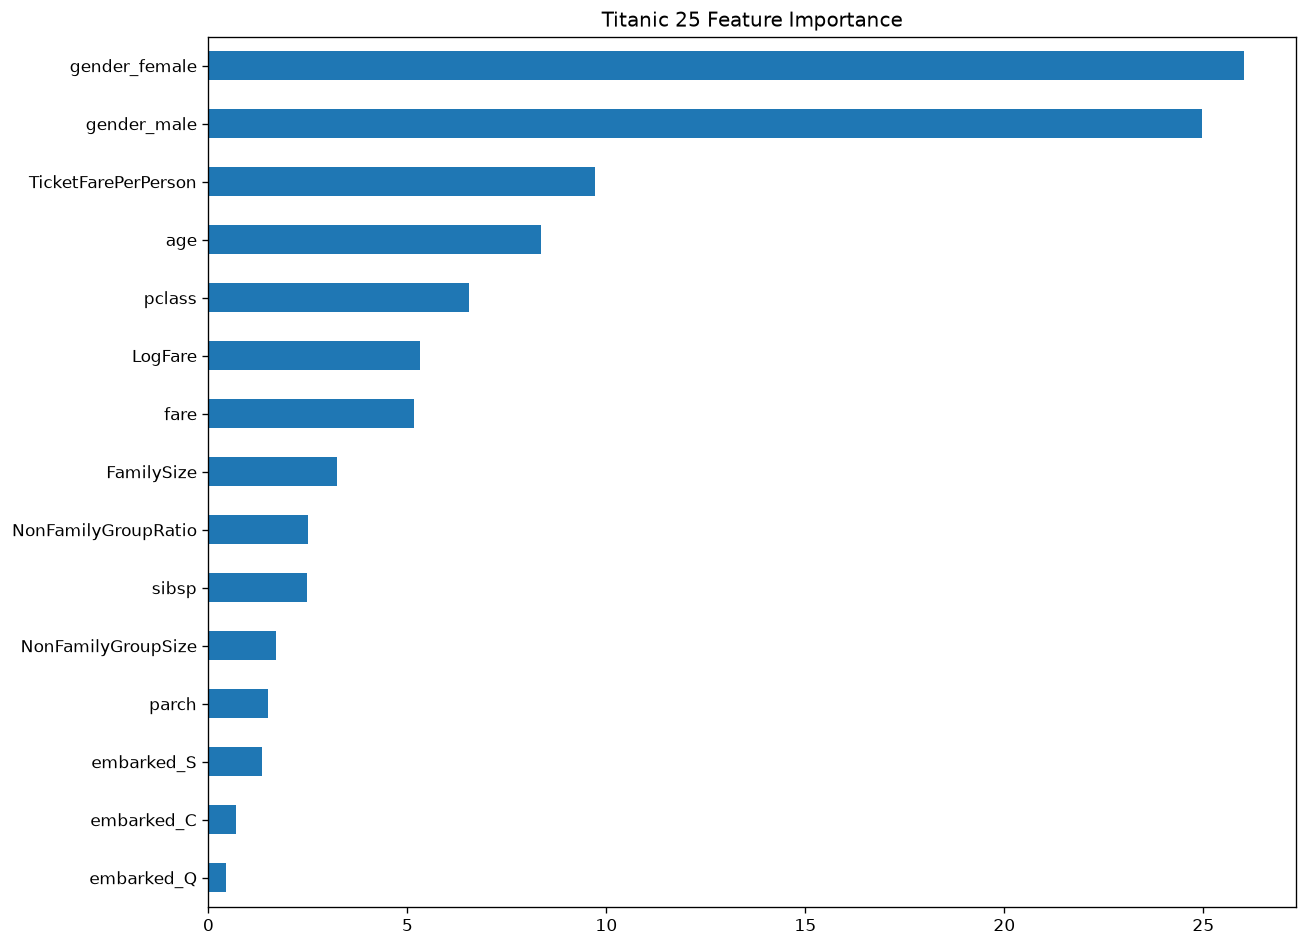

In [19]:
feature_importance = pd.Series(
    full_model.feature_importances_, index=X_full_model.columns, name="importance"
).sort_values(ascending=False)
ticket_feature_importance = feature_importance.reindex(ADDED_FEATURES)
print("전체 Feature Importance:\n", feature_importance.to_string())
print("\n세 Ticket Feature Importance:\n", ticket_feature_importance.to_string())
feature_importance.sort_values().plot.barh(figsize=(11, 8), title="Titanic 25 Feature Importance")
plt.tight_layout()
plt.show()


# 15. SHAP 분석 및 Summary Plot

최종 모델과 실제 `X_test_model`을 그대로 사용하며 SHAP 반환 형태만 최소 호환 처리한다.


SHAP shape: (393, 15) X_test_model shape: (393, 15)
세 Ticket Feature mean(|SHAP|):
 NonFamilyGroupSize     0.037456
TicketFarePerPerson    0.199704
NonFamilyGroupRatio    0.057431
titanic_25.ipynb:cell-41:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.


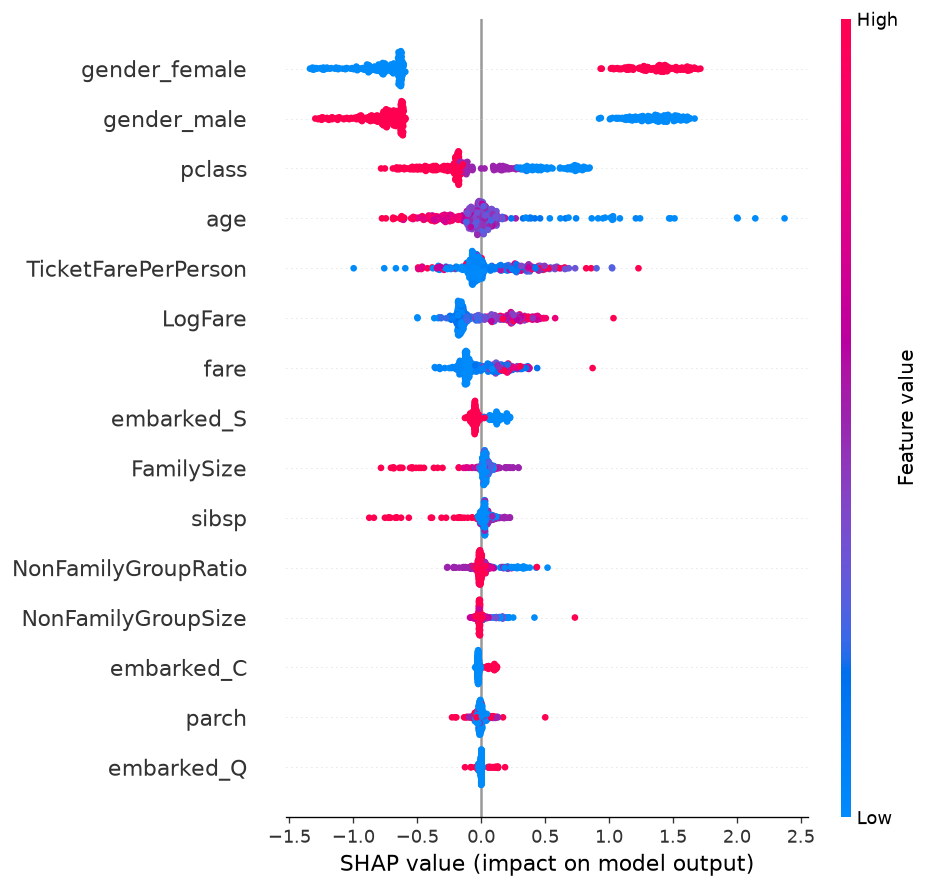

In [20]:
import shap
import skimage

explainer = shap.TreeExplainer(full_model)
shap_values = explainer.shap_values(X_test_model)

if isinstance(shap_values, list):
    shap_for_plot = np.asarray(shap_values[1] if len(shap_values) > 1 else shap_values[0])
else:
    shap_array = np.asarray(shap_values)
    if shap_array.ndim == 3:
        shap_for_plot = shap_array[:, :, 1]
    else:
        shap_for_plot = shap_array

assert shap_for_plot.shape == X_test_model.shape, (shap_for_plot.shape, X_test_model.shape)
ticket_shap_importance = pd.Series(
    np.abs(shap_for_plot).mean(axis=0), index=X_test_model.columns, name="mean_abs_shap"
).reindex(ADDED_FEATURES)
print("SHAP shape:", shap_for_plot.shape, "X_test_model shape:", X_test_model.shape)
print("세 Ticket Feature mean(|SHAP|):\n", ticket_shap_importance.to_string())
shap.summary_plot(shap_for_plot, X_test_model, show=False)
plt.tight_layout()
plt.show()


# 16. 일반 Confusion Matrix

Validation의 0/1 최종 예측을 사용한다.


TN: 124
FP: 19
FN: 18
TP: 68


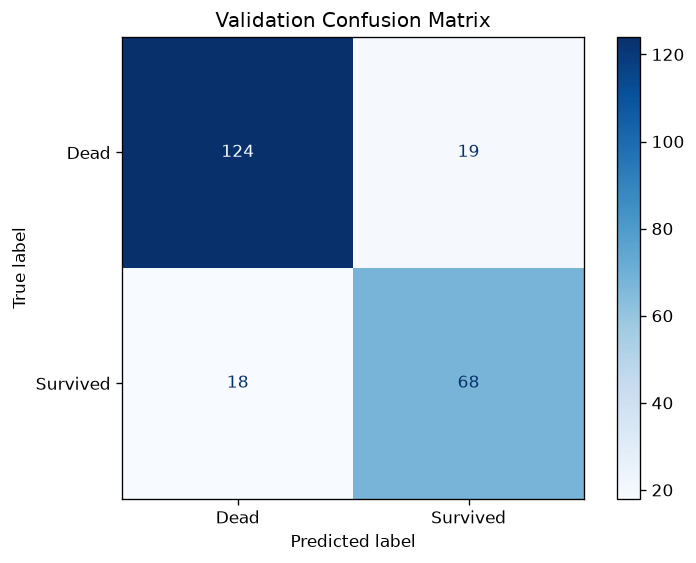

In [21]:
valid_prediction = model.predict(X_valid_model).astype(int)
cm = confusion_matrix(y_valid, valid_prediction, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print("TN:", int(tn))
print("FP:", int(fp))
print("FN:", int(fn))
print("TP:", int(tp))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dead", "Survived"])
display_cm.plot(cmap="Blues", values_format="d")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()


# 17. Normalized Confusion Matrix

행(True Label)을 기준으로 정규화하며 값을 정수로 변환하지 않는다.


TN: 0.867
FP: 0.133
FN: 0.209
TP: 0.791
TN + FP: 1.0
FN + TP: 1.0


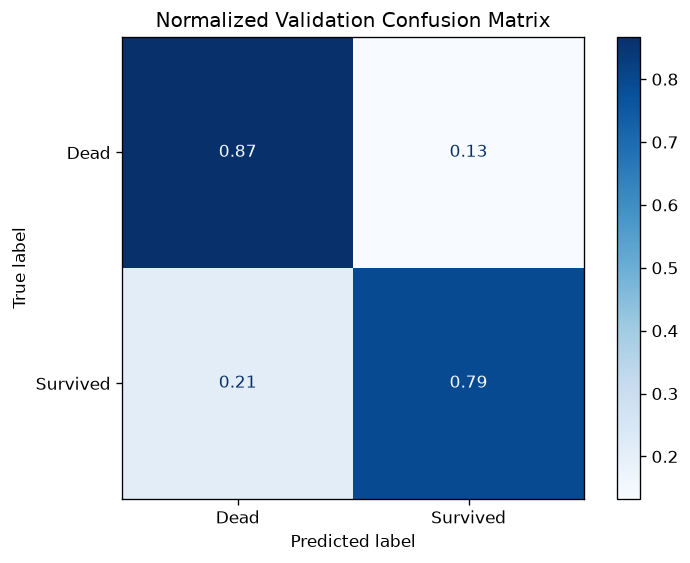

In [22]:
valid_prediction = model.predict(X_valid_model).astype(int)
normalized_cm = confusion_matrix(y_valid, valid_prediction, labels=[0, 1], normalize="true")
normalized_tn, normalized_fp, normalized_fn, normalized_tp = normalized_cm.ravel()
print(f"TN: {normalized_tn:.3f}")
print(f"FP: {normalized_fp:.3f}")
print(f"FN: {normalized_fn:.3f}")
print(f"TP: {normalized_tp:.3f}")
assert np.isclose(normalized_tn + normalized_fp, 1.0)
assert np.isclose(normalized_fn + normalized_tp, 1.0)
print("TN + FP:", normalized_tn + normalized_fp)
print("FN + TP:", normalized_fn + normalized_tp)
display_normalized_cm = ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=["Dead", "Survived"],
)
display_normalized_cm.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Validation Confusion Matrix")
plt.tight_layout()
plt.show()


# 18. 최종 실험 요약


In [23]:
individual_best_val = max(0.899333, 0.901935, 0.896975)
individual_best_cv = max(0.900966, 0.900752, 0.900748)
synergy_vs_individual = validation_auc > individual_best_val and cv_mean > individual_best_cv
adopt = validation_auc > 0.903480 and cv_mean > 0.900862 and gap <= 0.060675
decision = "채택" if adopt else "미채택"
synergy_assessment = "시너지 확인" if synergy_vs_individual else "일관된 시너지 없음"

summary = {
    "experiment": "Titanic 25",
    "baseline": "Titanic 21",
    "added_features": ADDED_FEATURES,
    "features": X_full_model.columns.tolist(),
    "train_auc": float(train_auc),
    "validation_auc": float(validation_auc),
    "gap": float(gap),
    "cv_mean": float(cv_mean),
    "cv_std": float(cv_std),
    "fold_scores": [float(value) for value in fold_scores],
    "vs_titanic_21": {
        "validation_auc_delta": float(baseline_val_delta),
        "cv_mean_delta": float(baseline_cv_delta),
        "gap_delta": float(baseline_gap_delta),
    },
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "normalized_confusion_matrix": {
        "tn": float(normalized_tn), "fp": float(normalized_fp),
        "fn": float(normalized_fn), "tp": float(normalized_tp),
    },
    "ticket_feature_importance": {key: float(value) for key, value in ticket_feature_importance.items()},
    "ticket_feature_mean_abs_shap": {key: float(value) for key, value in ticket_shap_importance.items()},
    "diagnostics": {
        "holdout_train": holdout_train_checks,
        "holdout_validation": holdout_valid_checks,
        "full_train": full_train_checks,
        "test": test_checks,
    },
    "submission_file": "submission/titanic_25_result.csv",
    "submission_checks": {key: bool(value) for key, value in submission_checks.items()},
    "execution_errors": 0,
    "synergy_assessment": synergy_assessment,
    "decision": decision,
}
summary_path = ROOT / "results" / "titanic_25_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Train AUC: {train_auc:.6f}")
print(f"Validation AUC: {validation_auc:.6f}")
print(f"Gap: {gap:.6f}")
print(f"CV Mean: {cv_mean:.6f}")
print(f"CV Std: {cv_std:.6f}")
print("Ticket Feature Importance:\n", ticket_feature_importance.to_string())
print("Ticket Feature mean(|SHAP|):\n", ticket_shap_importance.to_string())
print("Synergy:", synergy_assessment)
print("최종 판단:", decision)
print("Summary:", summary_path)


Train AUC: 0.967303
Validation AUC: 0.896731
Gap: 0.070572
CV Mean: 0.898545
CV Std: 0.014154
Ticket Feature Importance:
 NonFamilyGroupSize     1.700425
TicketFarePerPerson    9.722970
NonFamilyGroupRatio    2.508304
Ticket Feature mean(|SHAP|):
 NonFamilyGroupSize     0.037456
TicketFarePerPerson    0.199704
NonFamilyGroupRatio    0.057431
Synergy: 일관된 시너지 없음
최종 판단: 미채택
Summary: C:\dev\study\machine_learning\results\titanic_25_summary.json
